### PCA 개요

In [ ]:
# iris 데이터셋을 불러오기 위해 load_iris 함수를 import한다.
# iris 데이터셋은 붓꽃의 꽃받침/꽃잎 길이와 너비를 이용해 품종을 분류하는 대표 예제 데이터이다.
from sklearn.datasets import load_iris

# 표 형태의 데이터를 다루기 위해 pandas를 import한다.
import pandas as pd

# 그래프 시각화를 위해 matplotlib의 pyplot을 import한다.
import matplotlib.pyplot as plt

# 주피터 노트북 내부에서 그래프가 바로 출력되도록 설정한다.
%matplotlib inline

# 사이킷런에서 제공하는 iris 데이터셋을 불러온다.
iris = load_iris()

# iris 데이터셋의 4개 피처 이름을 직접 지정한다.
# sepal은 꽃받침, petal은 꽃잎을 의미한다.
columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

# iris.data는 numpy 배열 형태이므로 pandas DataFrame으로 변환한다.
# columns에는 위에서 지정한 피처 이름을 넣어준다.
irisDF = pd.DataFrame(iris.data, columns=columns)

# target 컬럼을 추가한다.
# target은 붓꽃의 품종을 숫자로 나타낸 값이다.
# 0: setosa, 1: versicolor, 2: virginica
irisDF['target'] = iris.target

# 데이터의 앞 3개 행을 출력하여 데이터 구조를 확인한다.
irisDF.head(3)

,sepal_length,sepal_width,petal_length,petal_width,target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0


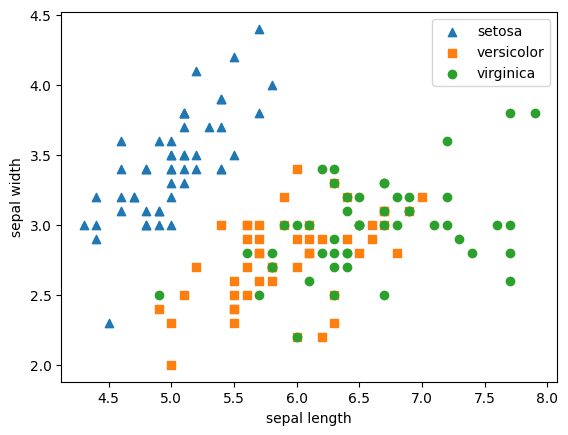

In [ ]:
# 각 품종을 그래프에서 다른 모양으로 표시하기 위해 marker 리스트를 만든다.
# setosa는 세모(^), versicolor는 네모(s), virginica는 동그라미(o)로 표현한다.
markers = ['^', 's', 'o']

# target 값은 setosa=0, versicolor=1, virginica=2이다.
# enumerate(markers)를 사용하면 i에는 0, 1, 2가 들어가고 marker에는 각 도형이 들어간다.
for i, marker in enumerate(markers):

    # target 값이 i인 데이터만 선택한 뒤, sepal_length 값을 x축 데이터로 사용한다.
    x_axis_data = irisDF[irisDF['target'] == i]['sepal_length']

    # target 값이 i인 데이터만 선택한 뒤, sepal_width 값을 y축 데이터로 사용한다.
    y_axis_data = irisDF[irisDF['target'] == i]['sepal_width']

    # 선택된 품종 데이터를 산점도로 그린다.
    # marker는 품종별로 다른 모양을 사용하고, label은 범례에 표시될 품종 이름이다.
    plt.scatter(
        x_axis_data,
        y_axis_data,
        marker=marker,
        label=iris.target_names[i]
    )

# 그래프에 범례를 표시한다.
plt.legend()

# x축 이름을 설정한다.
plt.xlabel('sepal length')

# y축 이름을 설정한다.
plt.ylabel('sepal width')

# 그래프를 화면에 출력한다.
plt.show()

In [ ]:
# PCA를 적용하기 전 데이터 표준화를 위해 StandardScaler를 import한다.
from sklearn.preprocessing import StandardScaler

# target 값을 제외한 피처 데이터만 선택한다.
# irisDF.iloc[:, :-1]은 마지막 컬럼인 target을 제외한 모든 피처를 의미한다.
# StandardScaler를 사용하여 각 피처의 평균은 0, 분산은 1이 되도록 표준화한다.
# PCA는 분산을 기준으로 주성분을 찾기 때문에, 피처 스케일이 다르면 특정 피처가 과도하게 영향을 줄 수 있다.
iris_scaled = StandardScaler().fit_transform(irisDF.iloc[:, :-1])

In [ ]:
# PCA를 수행하기 위해 PCA 클래스를 import한다.
from sklearn.decomposition import PCA

# PCA 객체를 생성한다.
# n_components=2는 기존 4개의 피처를 2개의 주성분으로 축소하겠다는 의미이다.
pca = PCA(n_components=2)

# 표준화된 iris 데이터에 PCA를 학습시킨다.
# 이 과정에서 데이터의 분산을 가장 잘 설명하는 주성분 방향을 찾는다.
pca.fit(iris_scaled)

# 학습된 PCA를 이용하여 원본 데이터를 2차원 주성분 데이터로 변환한다.
iris_pca = pca.transform(iris_scaled)

# PCA 변환 결과의 형태를 출력한다.
# 원래 iris 데이터는 150개 샘플과 4개 피처였지만,
# PCA 이후에는 150개 샘플과 2개 주성분 형태가 된다.
print(iris_pca.shape)

(150, 2)


In [ ]:
# PCA로 변환된 2개 주성분의 컬럼명을 지정한다.
pca_columns = ['pca_component_1', 'pca_component_2']

# PCA 변환 결과를 pandas DataFrame으로 변환한다.
# 각 컬럼은 첫 번째 주성분과 두 번째 주성분을 의미한다.
irisDF_pca = pd.DataFrame(iris_pca, columns=pca_columns)

# PCA 변환 데이터에도 품종 정보를 확인할 수 있도록 target 컬럼을 추가한다.
irisDF_pca['target'] = iris.target

# PCA 변환 데이터의 앞 3개 행을 출력한다.
irisDF_pca.head(3)

,pca_component_1,pca_component_2,target
0,-2.264703,0.480027,0
1,-2.080961,-0.674134,0
2,-2.364229,-0.341908,0


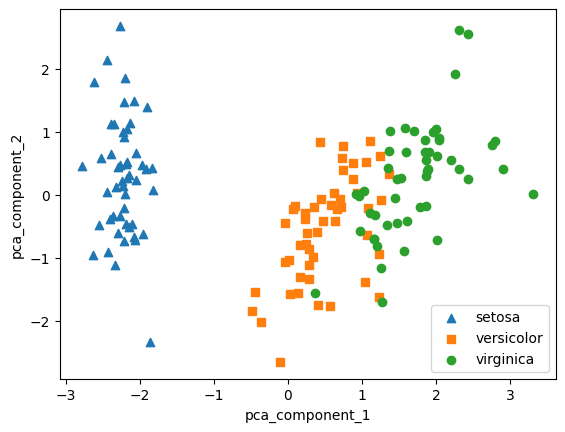

In [ ]:
# 각 품종을 그래프에서 다른 모양으로 나타내기 위한 marker 리스트이다.
# setosa는 세모, versicolor는 네모, virginica는 동그라미로 표시한다.
markers = ['^', 's', 'o']

# PCA 변환 데이터에서 품종별로 산점도를 그린다.
for i, marker in enumerate(markers):

    # target 값이 i인 데이터만 선택하고, 첫 번째 주성분 값을 x축 데이터로 사용한다.
    x_axis_data = irisDF_pca[irisDF_pca['target'] == i]['pca_component_1']

    # target 값이 i인 데이터만 선택하고, 두 번째 주성분 값을 y축 데이터로 사용한다.
    y_axis_data = irisDF_pca[irisDF_pca['target'] == i]['pca_component_2']

    # PCA 변환된 데이터를 산점도로 시각화한다.
    # 이를 통해 2차원으로 축소된 데이터에서 품종들이 얼마나 잘 구분되는지 확인할 수 있다.
    plt.scatter(
        x_axis_data,
        y_axis_data,
        marker=marker,
        label=iris.target_names[i]
    )

# 범례를 표시한다.
plt.legend()

# x축 이름을 첫 번째 주성분으로 설정한다.
plt.xlabel('pca_component_1')

# y축 이름을 두 번째 주성분으로 설정한다.
plt.ylabel('pca_component_2')

# 그래프를 출력한다.
plt.show()

In [ ]:
# PCA의 각 주성분이 원본 데이터의 분산을 얼마나 설명하는지 출력한다.
# explained_variance_ratio_는 각 주성분의 설명 분산 비율을 의미한다.
# 값이 클수록 해당 주성분이 원본 데이터의 정보를 많이 담고 있다는 뜻이다.
print(pca.explained_variance_ratio_)

[0.72962445 0.22850762]


In [ ]:
# 랜덤 포레스트 분류 모델을 사용하기 위해 import한다.
from sklearn.ensemble import RandomForestClassifier

# 교차 검증을 수행하기 위해 cross_val_score를 import한다.
from sklearn.model_selection import cross_val_score

# 평균 계산 등을 위해 numpy를 import한다.
import numpy as np

# 랜덤 포레스트 모델을 생성한다.
# random_state=156은 실행할 때마다 같은 결과가 나오도록 난수를 고정하는 역할을 한다.
rcf = RandomForestClassifier(random_state=156)

# 원본 iris 데이터를 이용해 3-fold 교차 검증을 수행한다.
# iris.data는 원본 피처 데이터이고, iris.target은 정답 레이블이다.
# scoring='accuracy'는 정확도를 평가 지표로 사용한다는 의미이다.
# cv=3은 데이터를 3개 fold로 나누어 검증한다는 의미이다.
scores = cross_val_score(
    rcf,
    iris.data,
    iris.target,
    scoring='accuracy',
    cv=3
)

# 각 fold별 정확도를 출력한다.
print('원본 데이터 교차 검증 개별 정확도:', scores)

# 3개 fold의 평균 정확도를 출력한다.
print('원본 데이터 평균 정확도:', np.mean(scores))

원본 데이터 교차 검증 개별 정확도: [0.98 0.94 0.96]
원본 데이터 평균 정확도: 0.96


In [ ]:
# PCA로 변환된 데이터 중 첫 번째 주성분과 두 번째 주성분만 선택한다.
pca_X = irisDF_pca[['pca_component_1', 'pca_component_2']]

# PCA 변환 데이터를 이용해 랜덤 포레스트 모델의 3-fold 교차 검증을 수행한다.
# 원본 데이터의 4개 피처 대신 PCA로 축소된 2개 피처만 사용한다.
scores_pca = cross_val_score(
    rcf,
    pca_X,
    iris.target,
    scoring='accuracy',
    cv=3
)

# PCA 변환 데이터의 fold별 정확도를 출력한다.
print('PCA 변환 데이터 교차 검증 개별 정확도:', scores_pca)

# PCA 변환 데이터의 평균 정확도를 출력한다.
# 이를 통해 차원 축소 후에도 분류 성능이 어느 정도 유지되는지 확인할 수 있다.
print('PCA 변환 데이터 평균 정확도:', np.mean(scores_pca))

PCA 변환 데이터 교차 검증 개별 정확도: [0.88 0.88 0.88]
PCA 변환 데이터 평균 정확도: 0.88


* credit card 데이터 세트 PCA 변환

In [ ]:
# 신용카드 데이터셋을 불러오기 위해 pandas를 import한다.
import pandas as pd

# 엑셀 파일에서 신용카드 데이터를 불러온다.
# header=1은 첫 번째 행을 건너뛰고 두 번째 행을 컬럼명으로 사용한다는 의미이다.
# sheet_name='Data'는 Data 시트에서 데이터를 읽겠다는 의미이다.
# iloc[0:, 1:]은 모든 행을 사용하되, 첫 번째 컬럼인 ID 컬럼은 제외하겠다는 의미이다.
df = pd.read_excel(
    'pca_credit_card.xls',
    header=1,
    sheet_name='Data'
).iloc[0:, 1:]

# 데이터의 행과 열 개수를 출력한다.
print(df.shape)

# 데이터의 앞 3개 행을 출력하여 구조를 확인한다.
df.head(3)

FileNotFoundError: [Errno 2] No such file or directory: 'pca_credit_card.xls'

In [ ]:
# 컬럼명을 더 이해하기 쉽게 변경한다.
# PAY_0은 실제로 첫 번째 월의 결제 상태를 의미하므로 PAY_1로 변경한다.
# default payment next month는 너무 길기 때문에 default로 변경한다.
df.rename(
    columns={
        'PAY_0': 'PAY_1',
        'default payment next month': 'default'
    },
    inplace=True
)

# 예측해야 하는 타깃값을 y_target에 저장한다.
# default는 다음 달 연체 여부를 의미하는 정답 레이블이다.
y_target = df['default']

# default 컬럼을 제외한 나머지 컬럼들을 피처 데이터로 사용한다.
X_features = df.drop('default', axis=1)

In [ ]:
# 피처 데이터의 정보를 확인한다.
# 컬럼명, 결측치 여부, 데이터 타입 등을 확인할 수 있다.
# 이를 통해 모델 학습 전에 데이터가 제대로 구성되어 있는지 점검한다.
X_features.info()

In [ ]:
# 상관관계 히트맵을 그리기 위해 seaborn을 import한다.
import seaborn as sns

# 그래프 출력을 위해 matplotlib의 pyplot을 import한다.
import matplotlib.pyplot as plt

# 주피터 노트북 안에서 그래프가 바로 출력되도록 설정한다.
%matplotlib inline

# 피처들 간의 상관계수를 계산한다.
# 상관계수는 두 변수 사이의 선형 관계 정도를 나타낸다.
corr = X_features.corr()

# 그래프 크기를 설정한다.
plt.figure(figsize=(14, 14))

# 상관계수 행렬을 히트맵으로 시각화한다.
# annot=True는 각 칸에 상관계수 값을 표시한다는 의미이다.
# fmt='.1g'는 숫자를 간단한 형식으로 표시하도록 설정하는 옵션이다.
sns.heatmap(
    corr,
    annot=True,
    fmt='.1g'
)

In [ ]:
# PCA를 수행하기 위해 PCA 클래스를 import한다.
from sklearn.decomposition import PCA

# 데이터 표준화를 위해 StandardScaler를 import한다.
from sklearn.preprocessing import StandardScaler

# BILL_AMT1부터 BILL_AMT6까지의 컬럼명을 생성한다.
# 이 컬럼들은 각 월의 청구 금액을 의미한다.
cols_bill = ['BILL_AMT' + str(i) for i in range(1, 7)]

# PAY_1부터 PAY_6까지의 컬럼명을 생성한다.
# 이 컬럼들은 각 월의 결제 상태를 의미한다.
cols_pay = ['PAY_' + str(i) for i in range(1, 7)]

# PAY_AMT1부터 PAY_AMT6까지의 컬럼명을 생성한다.
# 이 컬럼들은 각 월의 실제 납부 금액을 의미한다.
cols_amt = ['PAY_AMT' + str(i) for i in range(1, 7)]

# 청구 금액 컬럼명을 먼저 출력한다.
print(cols_bill)

# 청구 금액 컬럼 리스트에 결제 상태 컬럼들을 추가한다.
cols_bill.extend(cols_pay)

# 청구 금액 + 결제 상태 컬럼 리스트에 납부 금액 컬럼들을 추가한다.
cols_bill.extend(cols_amt)

# PCA를 적용할 대상 컬럼명을 출력한다.
print('대상 속성명:', cols_bill)

# StandardScaler 객체를 생성한다.
scaler = StandardScaler()

# 선택한 컬럼들에 대해 표준화를 수행한다.
# 평균은 0, 분산은 1이 되도록 변환한다.
df_cols_scaled = scaler.fit_transform(X_features[cols_bill])

# 표준화된 값을 다시 X_features의 해당 컬럼 위치에 대입한다.
# loc[:, cols_bill]은 선택한 컬럼 전체를 의미한다.
X_features.loc[:, cols_bill] = df_cols_scaled

# 2개의 주성분을 추출하는 PCA 객체를 생성한다.
pca = PCA(n_components=2)

# 표준화된 선택 컬럼 데이터에 PCA를 학습시킨다.
pca.fit(df_cols_scaled)

# 각 PCA Component가 원본 데이터의 분산을 얼마나 설명하는지 출력한다.
# 첫 번째 값은 첫 번째 주성분의 설명 분산 비율,
# 두 번째 값은 두 번째 주성분의 설명 분산 비율을 의미한다.
print('PCA Component별 변동성:', pca.explained_variance_ratio_)

In [ ]:
# numpy를 import한다.
# 평균 계산을 위해 사용한다.
import numpy as np

# 랜덤 포레스트 분류 모델을 import한다.
from sklearn.ensemble import RandomForestClassifier

# 교차 검증을 수행하기 위해 cross_val_score를 import한다.
from sklearn.model_selection import cross_val_score

# 랜덤 포레스트 모델을 생성한다.
# n_estimators=300은 300개의 결정 트리를 사용한다는 의미이다.
# random_state=156은 결과 재현성을 위한 설정이다.
rcf = RandomForestClassifier(
    n_estimators=300,
    random_state=156
)

# 원본 신용카드 피처 데이터를 이용해 3-fold 교차 검증을 수행한다.
# X_features는 전체 피처 데이터이고, y_target은 default 여부이다.
# scoring='accuracy'는 정확도를 평가 지표로 사용한다는 의미이다.
scores = cross_val_score(
    rcf,
    X_features,
    y_target,
    scoring='accuracy',
    cv=3
)

# 각 fold별 정확도를 출력한다.
print('CV=3 인 경우의 개별 Fold세트별 정확도:', scores)

# 전체 fold의 평균 정확도를 출력한다.
print('평균 정확도:{0:.4f}'.format(np.mean(scores)))

In [ ]:
# PCA 클래스를 import한다.
from sklearn.decomposition import PCA

# StandardScaler를 import한다.
from sklearn.preprocessing import StandardScaler

# StandardScaler 객체를 생성한다.
scaler = StandardScaler()

# 전체 피처 데이터 X_features에 대해 표준화를 수행한다.
# PCA는 분산을 기준으로 주성분을 찾기 때문에 스케일이 다른 피처들을 표준화해야 한다.
df_scaled = scaler.fit_transform(X_features)

# 6개의 주성분을 추출하는 PCA 객체를 생성한다.
# 원본 피처 전체를 6개의 PCA Component로 축소한다.
pca = PCA(n_components=6)

# 표준화된 전체 피처 데이터에 PCA를 적용하여 6차원 데이터로 변환한다.
df_pca = pca.fit_transform(df_scaled)

# PCA 변환된 데이터를 이용해 랜덤 포레스트 모델의 3-fold 교차 검증을 수행한다.
# 원본 피처 대신 6개의 주성분만 사용하여 분류 성능을 평가한다.
scores_pca = cross_val_score(
    rcf,
    df_pca,
    y_target,
    scoring='accuracy',
    cv=3
)

# PCA 변환 데이터의 각 fold별 정확도를 출력한다.
print('CV=3 인 경우의 PCA 변환된 개별 Fold세트별 정확도:', scores_pca)

# PCA 변환 데이터의 평균 정확도를 출력한다.
# 원본 데이터 정확도와 비교하여 차원 축소 후 성능이 얼마나 유지되는지 확인한다.
print('PCA 변환 데이터 셋 평균 정확도:{0:.4f}'.format(np.mean(scores_pca)))